<a href="https://colab.research.google.com/github/KevinCallejas93/caso_practico_aplicado/blob/main/Tarea_Produccion_Software.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Pega aquí el enlace que acabas de copiar
url = "https://raw.githubusercontent.com/KevinCallejas93/caso_practico_aplicado/refs/heads/main/Prestige_modificado.csv"

# Cargamos los datos
df = pd.read_csv(url, sep=';')

# Comprobamos que funciona viendo las primeras 5 filas
df.head()

,occupation,education,income,women,prestige,census,type_num
0,gov.administrators,13.11,12351,11.16,68.8,1113,1
1,general.managers,12.26,25879,4.02,69.1,1130,1
2,accountants,12.77,9271,15.70,63.4,1171,1
3,purchasing.officers,11.42,8865,9.11,56.8,1175,1
4,chemists,14.62,8403,11.68,73.5,2111,1


In [2]:
# 1. Validamos cuántas ocupaciones (filas) y datos (columnas) hay
print("Dimensiones del dataset (Filas, Columnas):", df.shape)

# 2. Revisamos si hay celdas vacías (nulos)
print("\nValores nulos encontrados por columna:")
print(df.isnull().sum())

# 3. Revisamos si hay filas repetidas
print("\nRegistros duplicados:", df.duplicated().sum())

# 4. Generamos estadística descriptiva (promedios, mínimos, máximos)
print("\nResumen estadístico de las variables numéricas:")
print(df.describe())

Dimensiones del dataset (Filas, Columnas): (102, 7)

Valores nulos encontrados por columna:
occupation    0
education     0
income        0
women         0
prestige      0
census        0
type_num      0
dtype: int64

Registros duplicados: 0

Resumen estadístico de las variables numéricas:
        education        income       women    prestige       census  \
count  102.000000    102.000000  102.000000  102.000000   102.000000   
mean    10.738039   6797.901961   28.979020   46.833333  5401.774510   
std      2.728444   4245.922227   31.724931   17.204486  2644.993215   
min      6.380000    611.000000    0.000000   14.800000  1113.000000   
25%      8.445000   4106.000000    3.592500   35.225000  3120.500000   
50%     10.540000   5930.500000   13.600000   43.600000  5135.000000   
75%     12.647500   8187.250000   52.202500   59.275000  8312.500000   
max     15.970000  25879.000000   97.510000   87.200000  9517.000000   

         type_num  
count  102.000000  
mean     1.843137  


In [3]:
# 1. Seleccionamos solo las variables con números
variables_numericas = df.select_dtypes(include=['int64', 'float64'])

# 2. Calculamos la matriz de correlación
matriz_correlacion = variables_numericas.corr()

# 3. Mostramos las correlaciones ordenadas respecto al Prestige
print("CORRELACIÓN CON EL PRESTIGIO (ORDENADA):")
print(matriz_correlacion['prestige'].sort_values(ascending=False).round(3))

CORRELACIÓN CON EL PRESTIGIO (ORDENADA):
prestige     1.000
education    0.850
income       0.715
women       -0.118
type_num    -0.465
census      -0.635
Name: prestige, dtype: float64


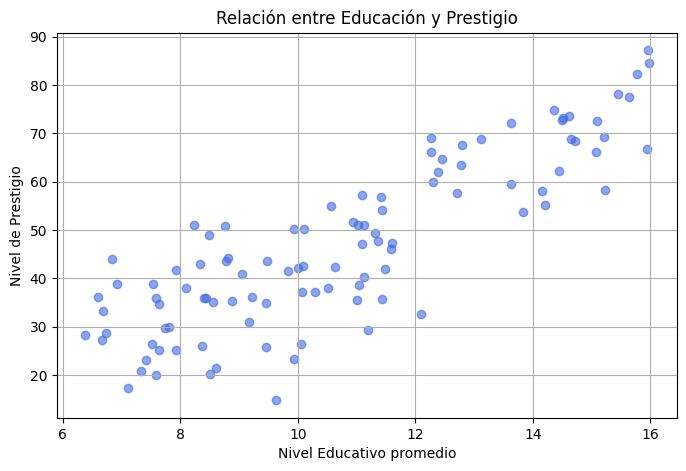

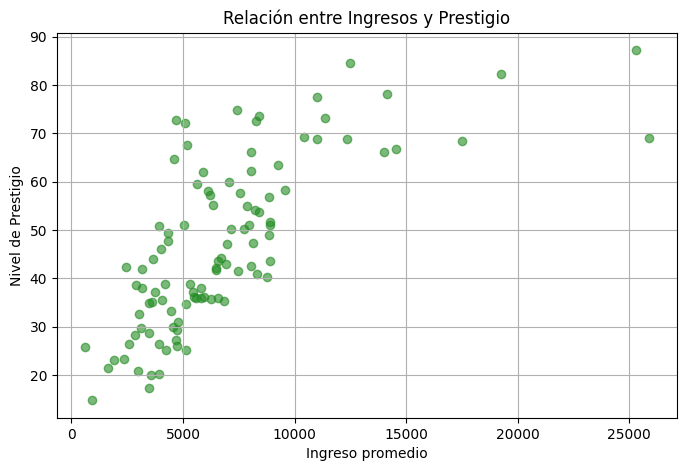

In [4]:
import matplotlib.pyplot as plt

# Gráfica de dispersión: Educación vs Prestigio
plt.figure(figsize=(8,5))
plt.scatter(df['education'], df['prestige'], color='royalblue', alpha=0.6)
plt.title('Relación entre Educación y Prestigio')
plt.xlabel('Nivel Educativo promedio')
plt.ylabel('Nivel de Prestigio')
plt.grid(True)
plt.show()

# Gráfica de dispersión: Ingresos vs Prestigio
plt.figure(figsize=(8,5))
plt.scatter(df['income'], df['prestige'], color='forestgreen', alpha=0.6)
plt.title('Relación entre Ingresos y Prestigio')
plt.xlabel('Ingreso promedio')
plt.ylabel('Nivel de Prestigio')
plt.grid(True)
plt.show()

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Seleccionamos las columnas para agrupar
columnas_cluster = ["education", "income", "women", "prestige", "type_num"]
X = df[columnas_cluster].copy()

# 2. Escalamos los datos (los normalizamos)
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

print("Datos listos y normalizados para el algoritmo.")

Datos listos y normalizados para el algoritmo.


In [6]:
# Modelo con 4 grupos
modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)

# Modelo con 5 grupos
modelo_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)

# Vemos el promedio de cada grupo para el modelo de 4
print("CENTROIDES (PROMEDIOS) DEL MODELO DE 4 GRUPOS:")
print(df.groupby('Cluster_4')[columnas_cluster].mean().round(2))

CENTROIDES (PROMEDIOS) DEL MODELO DE 4 GRUPOS:
           education    income  women  prestige  type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00


In [7]:
print("CENTROIDES (PROMEDIOS) DEL MODELO DE 5 GRUPOS:")
print(df.groupby('Cluster_5')[columnas_cluster].mean().round(2))

CENTROIDES (PROMEDIOS) DEL MODELO DE 5 GRUPOS:
           education    income  women  prestige  type_num
Cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00


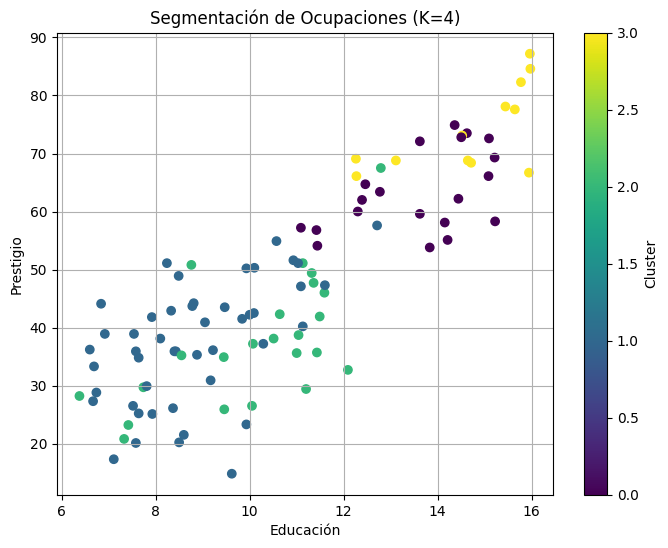

In [8]:
plt.figure(figsize=(8,6))
# Usamos el color (c) basado en el Cluster_4
plt.scatter(df["education"], df["prestige"], c=df["Cluster_4"], cmap='viridis')
plt.xlabel("Educación")
plt.ylabel("Prestigio")
plt.title("Segmentación de Ocupaciones (K=4)")
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()